<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Test%2FNovo_dataset/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Seção 1: Introdução
----------------------------------------

## Contextualização

### O K-means, por ser um algoritmo de clustering, é extremamente útil para identificação de padrões. Nesse sentido, focaremos no seguinte problema de negócio:

Uma determinada loja possui dados sobre seus clientes e pretende desenvolver um trabalho de análise de dados para compreender melhor o comportamento e características de cada perfil de cliente. A loja pretende promover promoções, descontos e ações publicitárias para fortalecer as vendas de produtos específicos, identificar quais produtos e setores da loja são mais frequentados por determinados perfis de clientes e criar estratégias de mercado para engajar grupos de clientes específicos. 

## Objetivo

### Buscamos responder a seguinte pergunta: *Quais são os principais perfis/segmentos de clientes da loja com base em informações gerais sobre renda, ocupação, escolaridade, etc?*



## Descrição dos Dados

### O Dataset escolhido é o "Segmentation data", oriundo do [Kaggle](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv). O dono da loja obtém informações sobre os clientes por meio de cartões de fidelidade. Em relação ao significado de cada coluna do Dataset, o seguinte dicionário traz uma boa descrição:

* Customer ID (int)
    - ID único que identifica cada cliente da loja

* Sex (int) - Qualitativa, codificada
    - Indica o sexo do cliente.
    >  0: Homem,  1: Mulher 

* Matiral Status (int) - Qualitativa, codificada
    - Estado civil do cliente
    > 0: solteiro, 1: não solteiro (casado/divorciado/separado/viuvo)

* Age (int) - Quantitativa
    - Idade do cliente

* Education (int) - Qualitativa, codificada
    - Escolaridade do cliente
    > 0: desconhecido, 1: Ensino médio, 2: Graduação, 3: Pós-Graduação 

* Income (int) - Quantitativa
     - Renda anual do cliente em dólares

* Occupation (int) - Qualitativa, codificada
   - Categoria da ocupação profissional do cliente
   > 0: desempregado, 1: empregado regular, 2: empregado em gestão / funcionário autônomo / funcionário altamente qualificado 

* Settlement Size (int) - Qualitativa, codificada
     - Tamanho da cidade na qual o cliente mora
     >0: cidade pequena, 1: cidade de tamanho média, 2: cidade grande



-----------------------------------------------
#Seção 2: Análise Exploratória de Dados (EDA)
-----------------------------------------------
● 2.1. Carregamento e Limpeza dos Dados: Importe os dados e mostre os primeiros
passos de verificação (ex: .info(), .describe(), .isnull() .sum()). Descreva como tratou
dados faltantes, duplicados ou inconsistentes.



● 2.3. Análise Bivariada e Multivariada: Investigue a relação entre as variáveis. Use
gráficos (scatter plots, heatmaps de correlação) e tabelas para identificar padrões,
tendências e correlações.

● 2.4. Insights da Eda: Faça um resumo do que você aprendeu nesta fase. A análise
confirmou sua hipótese inicial? Surgiram novas perguntas? Quais variáveis parecem
ser mais promissoras para a modelagem?

In [11]:
install.packages("GGally")
library(GGally)
library(ggplot2)
library(tidyr)
library(dplyr)


Installing package into ‘/home/idhac/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [12]:
install.packages("fastDummies")
library(fastDummies)

Installing package into ‘/home/idhac/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [34]:
dataset <- read.csv ("segmentation_data.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

[1] "Dataset Instalado com Sucesso"


In [39]:
cat("Total de Ids duplicados no dataset:", sum(duplicated(dataset[1])), "\n")
cat("Total de clientes duplicados no dataset:", sum(duplicated(dataset_sem_id[2:8]))) # considerando todas as colunas menos o ID

Total de Ids duplicados no dataset: 0 
Total de clientes duplicados no dataset: 0

In [60]:
check_NA <- function(c) {
    cat("NAs:", sum(is.na(c) | c == ""))
}

cnt = 1
for (col in dataset) {
    cat(colnames(dataset)[cnt], "- ")
    check_NA(col)
    cat("\n")
    cnt <- cnt + 1
}


ID - NAs: 0
Sex - NAs: 0
Marital.status - NAs: 0
Age - NAs: 0
Education - NAs: 0
Income - NAs: 0
Occupation - NAs: 0
Settlement.size - NAs: 0


In [40]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == ""), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c), 2),"\t"))
    cat(paste("Mediana", round(median(c), 2),"\n"))

  } else {
      c_filtrado <- c[c != "" & !is.na(c)]
      cat(paste("Máximo caracteres:", max(nchar(c_filtrado)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c_filtrado)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}

In [42]:
#Coluna Sexo
cat("Sex\n")
info_colun_num(dataset$Sex)
cat("-------------------------------------------------\n")
#Coluna estado civil
cat("Matiral status\n")
info_colun_num(dataset$Marital.status)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Age\n")
info_colun_num(dataset$Age)
cat("-------------------------------------------------\n")
#Coluna Salario Anual
cat("Education level\n")
info_colun_num(dataset$Education)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Income\n")
info_colun_num(dataset$Income)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Occupation type\n")
info_colun_num(dataset$Occupation)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Settlement size\n")
info_colun_num(dataset$Settlement.size)
cat("-------------------------------------------------\n")
#Coluna Familiares
# cat("Family Size\n")
# info_colun_num(dataset$Family.Size)
# cat("-------------------------------------------------\n")

Sex
Tipo: integer | NAs: 0 | Únicos: 2 
5 primeiros elementos: 0  -  1  -  0  -  0  -  0 
Mínimo: 0 	1ºQuart: 0 	Média: 0.46 	3ºQuart: 1 	Máximo: 1 
Desvio Padrão: 0.5 	Mediana 0 
-------------------------------------------------
Matiral status
Tipo: integer | NAs: 0 | Únicos: 2 
5 primeiros elementos: 0  -  1  -  0  -  0  -  0 
Mínimo: 0 	1ºQuart: 0 	Média: 0.5 	3ºQuart: 1 	Máximo: 1 
Desvio Padrão: 0.5 	Mediana 0 
-------------------------------------------------
Age
Tipo: integer | NAs: 0 | Únicos: 58 
5 primeiros elementos: 67  -  22  -  49  -  45  -  53 
Mínimo: 18 	1ºQuart: 27 	Média: 35.91 	3ºQuart: 42 	Máximo: 76 
Desvio Padrão: 11.72 	Mediana 33 
-------------------------------------------------
Education level
Tipo: integer | NAs: 0 | Únicos: 4 
5 primeiros elementos: 2  -  1  -  1  -  1  -  1 
Mínimo: 0 	1ºQuart: 1 	Média: 1.04 	3ºQuart: 1 	Máximo: 3 
Desvio Padrão: 0.6 	Mediana 1 
-------------------------------------------------
Income
Tipo: integer | NAs: 0 | Únicos: 1982

## Análise Univariada
● 2.2. Análise Univariada: Explore as variáveis individualmente. Use gráficos
(histogramas, boxplots, etc) e métricas para entender a distribuição e as características
de cada variável relevante. Comente suas observações.

In [73]:
dataset_sem_id <- dataset[2:8]

## Sex

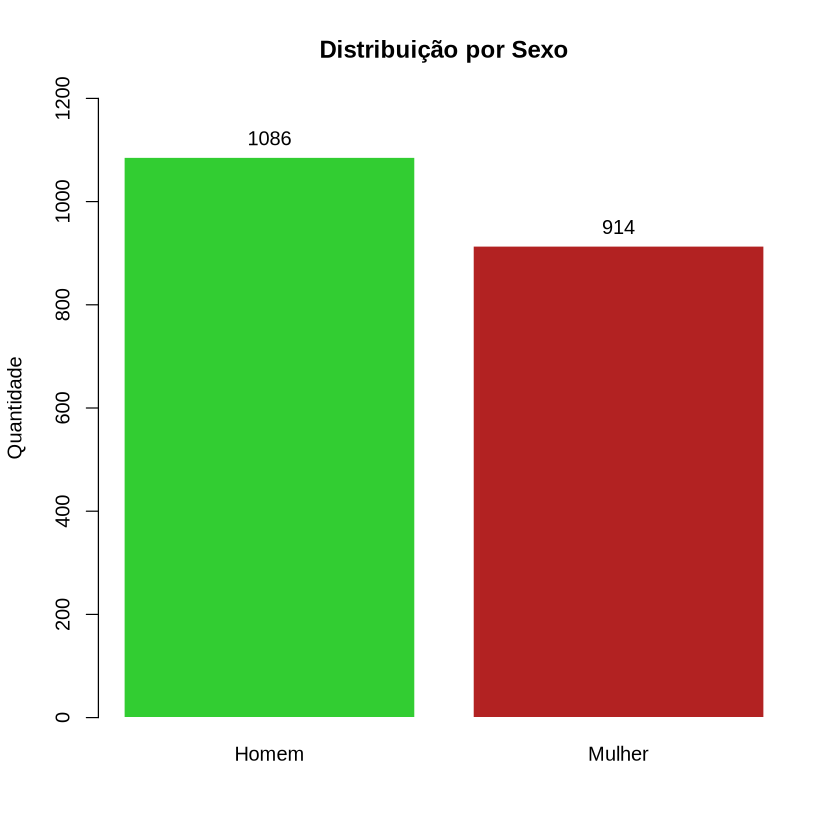

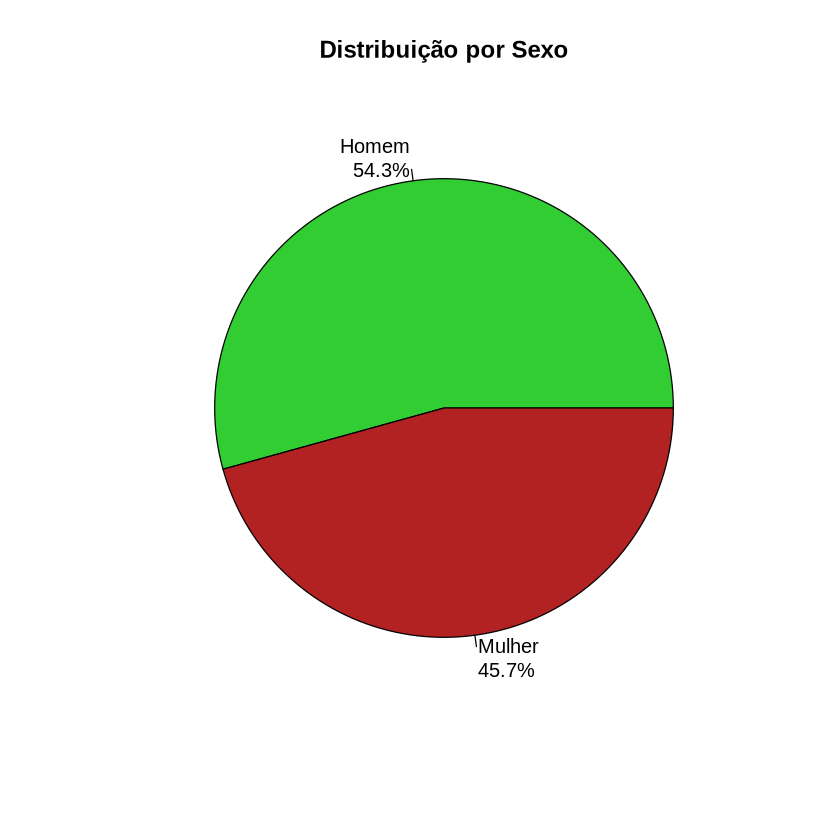

In [119]:
par(bg = "white")

Sex_var <- table(dataset_sem_id$Sex)

bp <- barplot(
    Sex_var,
    names.arg = c("Homem", "Mulher"),
    main = "Distribuição por Sexo",
    ylab = "Quantidade",
    col = c("limegreen", "firebrick"),
    border = "white",
    ylim = c(0, 1200)
)

text(bp, contagem, labels = Sex_var, pos = 3)

contagem <- table(dataset_sem_id$Sex)

pizza <- pie(
    Sex_var,
    main = "Distribuição por Sexo",
    labels = paste0(
        c("Homem", "Mulher"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("limegreen", "firebrick"),
    
)

No nosso dataset, percebe-se que existe uma maior represetação de homens do que mulheres, embora pequena.

## Marital Status

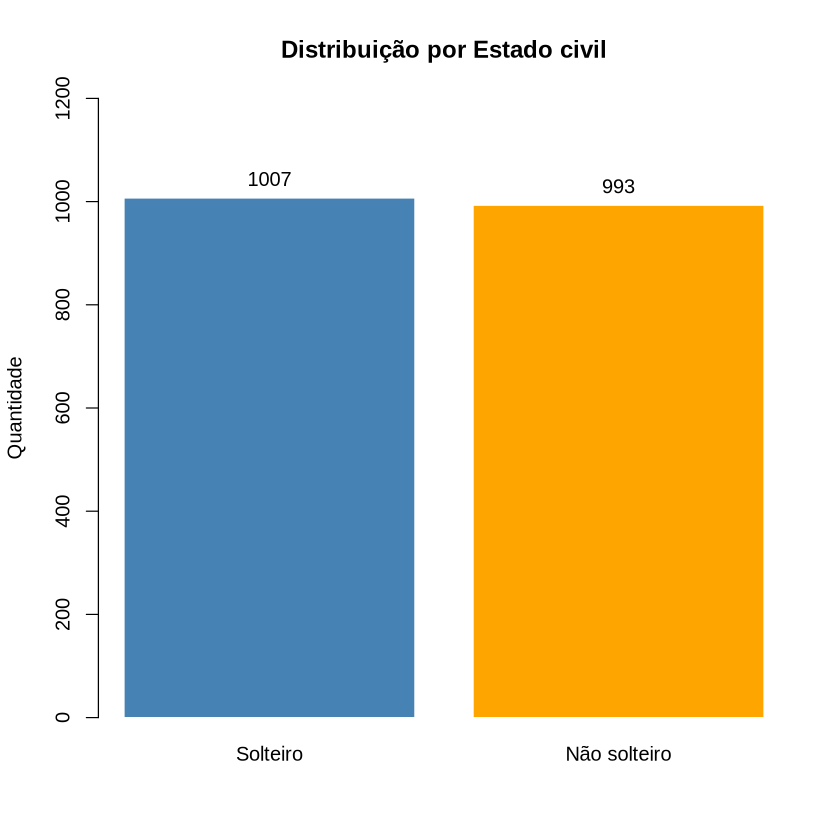

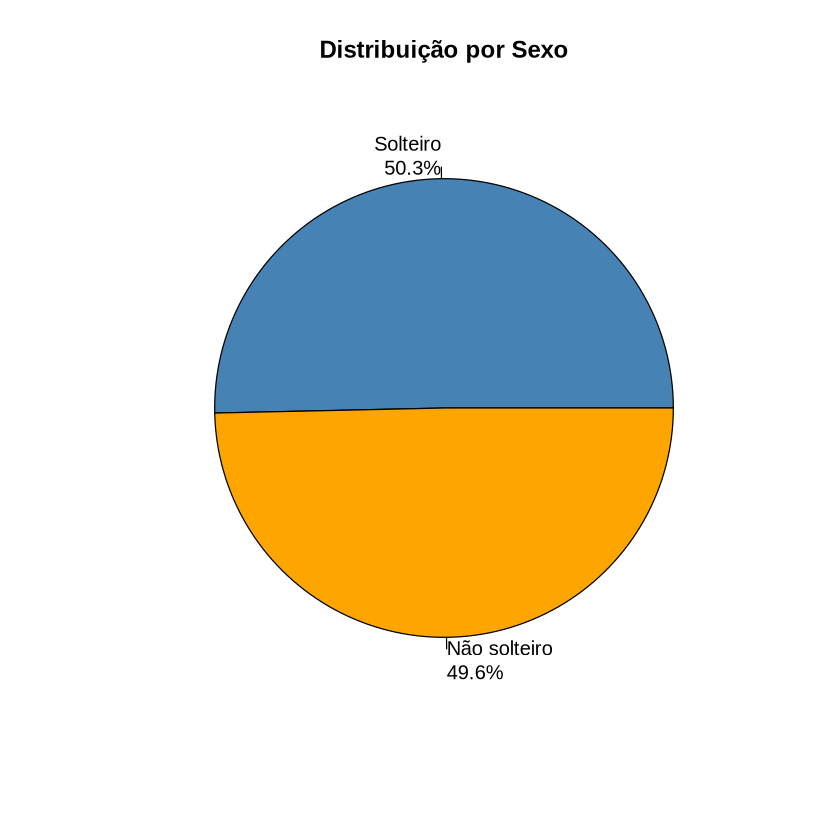

In [129]:
par(bg = "white")

Marital_var <- table(dataset_sem_id$Marital.status)

bp <- barplot(
    Marital_var,
    names.arg = c("Solteiro", "Não solteiro"),
    main = "Distribuição por Estado civil",
    ylab = "Quantidade",
    col = c("steelblue", "orange"),
    border = "white",
    ylim = c(0, 1200)
)

text(bp, contagem, labels = Marital_var, pos = 3)

contagem <- table(dataset_sem_id$Marital.status)

pizza <- pie(
    Marital_var,
    main = "Distribuição por Sexo",
    labels = paste0(
        c("Solteiro", "Não solteiro"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("steelblue", "orange"),
    
)

Neste dataset, a disparidade entre as duas categorias de estado civil é baixa.

## Age

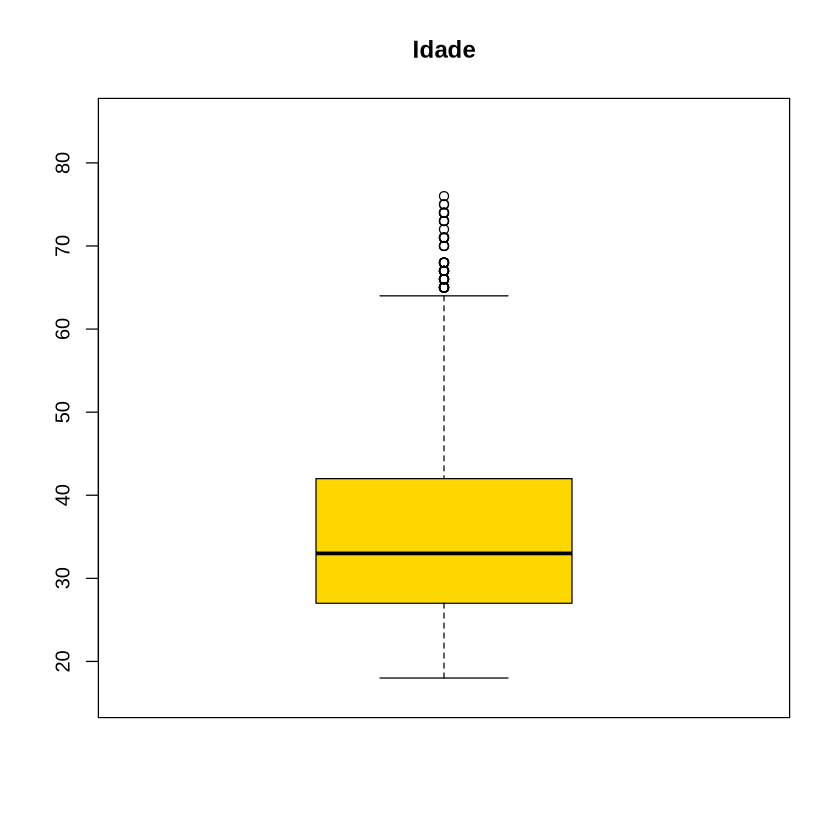

In [151]:
par(bg = "white")

Age_var <- dataset_sem_id$Age

bp <- boxplot(
    Age_var,
    main = "Idade",
    col = "gold",
    ylim = c(16, 85)
)

#text(bp, contagem, labels = Age_var, pos = 3)

# contagem <- table(dataset_sem_id$Age)

# pizza <- pie(
#     Age_var,
#     main = "Distribuição por Sexo",
#     labels = paste0(
#         c("Solteiro", "Não solteiro"),
#         "\n",
#         round(contagem / sum(contagem) * 100, 1),
#         "%"
#     ),
#     col = c("steelblue", "orange"),
    
# )

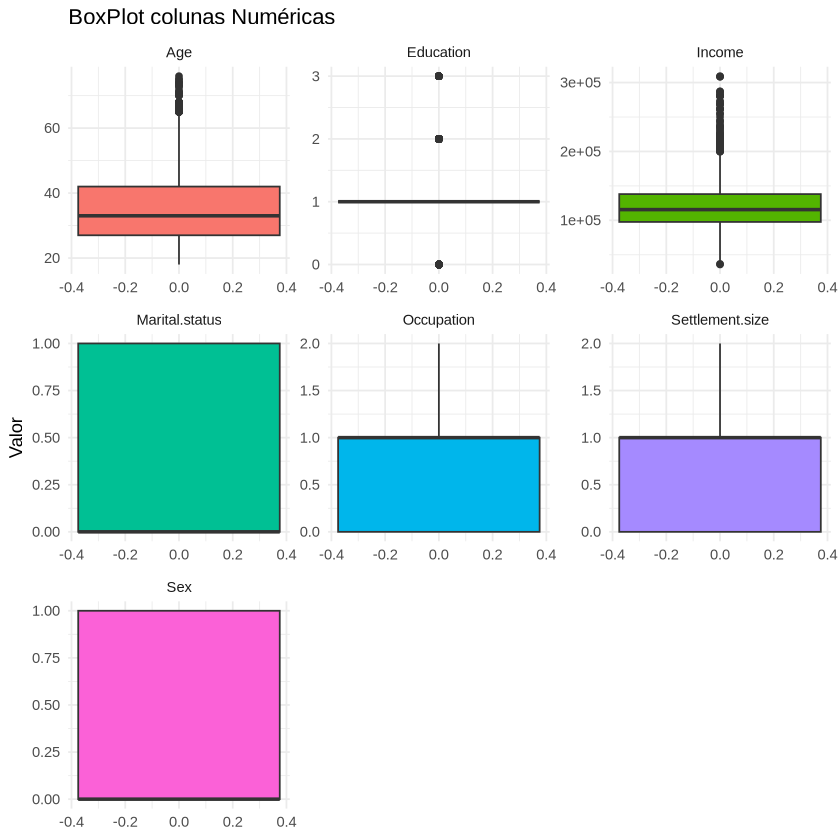

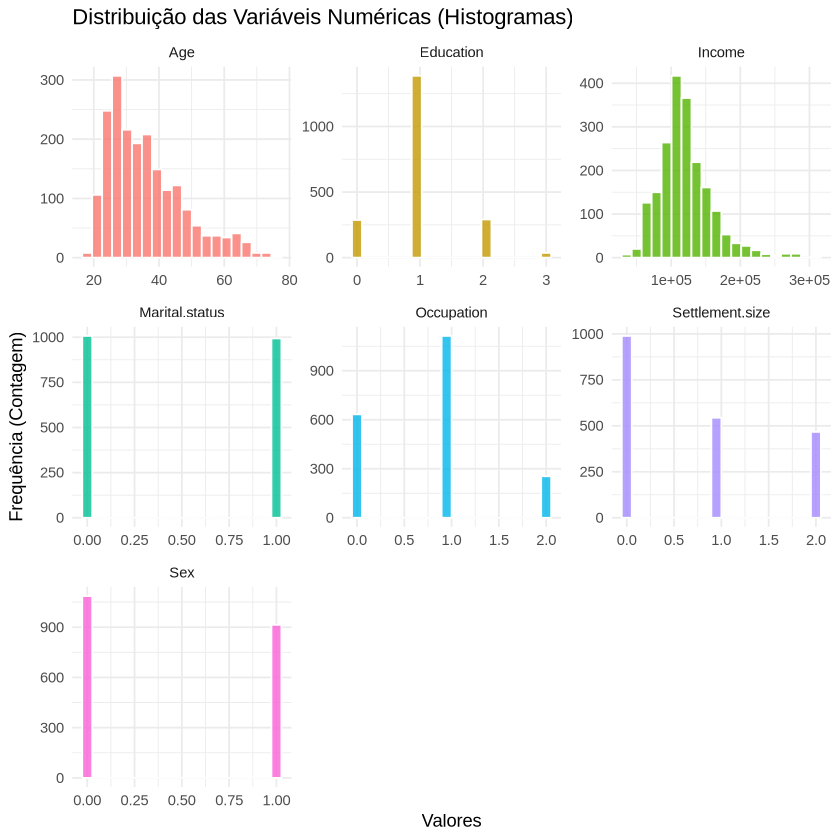

In [78]:
dados_longo <- dataset_sem_id %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(y = Valor, fill = Variavel)) +
  geom_boxplot() +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "BoxPlot colunas Numéricas")

dados_longo <- dataset_sem_id %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(x = Valor, fill = Variavel)) +
  geom_histogram(bins = 20, color = "white", alpha = 0.8) +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    title = "Distribuição das Variáveis Numéricas (Histogramas)",
    x = "Valores",
    y = "Frequência (Contagem)"
  )

In [ ]:
dataset_numerico <- dataset_sem_id[, sapply(dataset_sem_id, is.numeric)]
ggcorr(dataset_numerico, label=T)

In [ ]:
ggpairs(dataset, lower = list(continuous = "smooth"))

In [ ]:
# dataset$Profession[dataset$Profession == ""] <- "Sem Profissão"
# #maiores de 18 anos
# dataset_18 <- dataset[which(dataset$Age >= 18), ]
# cat("Outliers removidos:", nrow(dataset) - nrow(dataset_18), "linhas.\n")
# #idade minima pela lei
# dataset_filtrado <- dataset_18[which((dataset_18$Age - dataset_18$Work.Experience) >= 14), ]
# cat("Outliers removidos:", nrow(dataset_18) - nrow(dataset_filtrado), "linhas.\n")

In [ ]:
summary(dataset)

-----------------------------------------------
#Seção 3: Validação Estatística (Teste de Hipóteses)
-----------------------------------------------
● 3.1. Definição das Hipóteses: Declare formalmente a Hipótese Nula e a Hipótese
Alternativa. As hipóteses devem estar relacionadas aos padrões identificados na EDA.

● 3.2. Escolha a Execução do Teste: Utilize o teste adequado para o seu tema (Teste t,
ANOVA, Qui-quadrado, Teste de Correlação de Pearson, etc.).

● 3.3. Interpretação do p-valor: Com base em um nível de significância (ex: 5%),
determine se há evidências para rejeitar a hipótese nula e valide se o padrão encontrado
na EDA é estatisticamente significante.

-----------------------------------------------
#Seção 4: Pré-processamento e Aplicação da Técnica
-----------------------------------------------
● 4.1. Preparação dos Dados para o Modelo: Descreva e execute os passos necessários
para preparar os dados para a sua técnica específica (ex: normalização/padronização
para K-Means, criação de variáveis dummy para regressão, etc.).

● 4.2. Modelagem: Aplicação do algoritmo do seu tema. Explique a escolha de
parâmetros, se houver.

In [ ]:
df = dataset[,!(names(dataset) %in% c("ID"))]


# dataset_preparado <- dummy_cols(
#   dataset_f,
#   select_columns = c("Gender","Profession"),
#   remove_selected_columns = TRUE
# )

head(df)

dataset_final<- as.data.frame(scale(df))
head(dataset_final)

In [ ]:
n_clusters <- 10

wss <- numeric(n_clusters)

set.seed(123)

for (i in 1:n_clusters) {
  km.out <- kmeans(dataset_final, centers = i, nstart = 20)
  wss[i] <- km.out$tot.withinss
}

wss_df <- tibble(clusters = 1:n_clusters, wss = wss)

scree_plot <- ggplot(wss_df, aes(x = clusters, y = wss, group = 1)) +
    geom_point(size = 4)+
    geom_line() +
    scale_x_continuous(breaks = c(2, 4, 6, 8, 10)) +
    xlab('Number of clusters')
scree_plot


In [ ]:
scree_plot +
  geom_hline(
    yintercept = wss,
    linetype = 'dashed',
    color = 'gray60',
    linewidth = 0.5
  )

In [ ]:
km.out <- kmeans(dataset_final, centers = 4, nstart = 20)
print(km.out)

-----------------------------------------------
#Seção 5: Resultados e Interpretação
-----------------------------------------------
● 5.1. Apresentação dos Resultados: Mostre a saída do seu modelo de forma clara.
Pode ser uma tabela com coeficientes, uma visualização dos clusters, uma imagem da
árvore de decisão, etc.

● 5.2. Análise Crítica dos Resultados: Esta é a parte mais importante. Traduza a
saída técnica em uma explicação clara e objetiva.
  
○ Exemplo para K-Means: "O modelo identificou 3 clusters. O Cluster 1, que
chamamos de 'Clientes Econômicos', é caracterizado por... O Cluster 2,
'Clientes Premium', por sua vez..."
  
○ Exemplo para Regressão Linear: "O coeficiente para a variável 'área_m2' foi
de 850. Isso sugere que, mantendo as outras variáveis constantes, cada metro
quadrado adicional está associado a um aumento de R$850 no preço do
aluguel."

-----------------------------------------------
#Seção 6: Conclusão
-----------------------------------------------
● 6.1. Resumo dos Insights: Sintetize as principais descobertas do seu projeto.
Responda diretamente à pergunta que você se propôs a investigar na introdução.

● 6.2. Recomendações Práticas: Com base nos seus achados, o que você recomendaria
para uma empresa ou área de estudo? Proponha 1 ou 2 ações concretas.

● 6.3. Limitações e Próximos Passos: Nenhum projeto é perfeito. Discuta as limitações
da sua análise (ex: poucos dados, variáveis faltantes, simplicidade do modelo).